In [14]:
import zipfile
path = zipfile.ZipFile("/content/Cat_And_Dog.v1i.yolov11.zip")
path.extractall()

In [15]:
!pip install ultralytics

In [20]:
!pip install gradio

In [16]:
from ultralytics import YOLO

In [17]:
model = YOLO('yolo26n.pt')

In [18]:
pred = model.predict("/content/racing-bicycle.webp")


image 1/1 /content/racing-bicycle.webp: 448x640 1 bicycle, 75.0ms
Speed: 2.2ms preprocess, 75.0ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
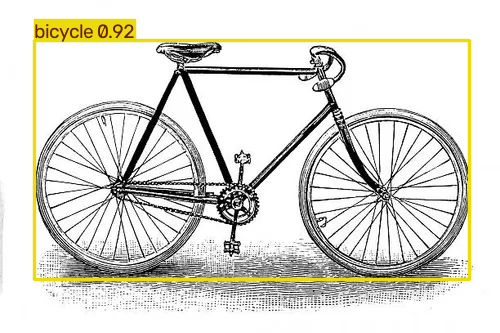

In [19]:
pred[0].plot()

In [21]:
import gradio as gr
import cv2

def detect_objects(image_path):
    # Perform prediction
    results = model.predict(image_path)

    # Plot results on the image
    plotted_image = results[0].plot()

    # Gradio expects numpy array in RGB format
    return cv2.cvtColor(plotted_image, cv2.COLOR_BGR2RGB)

In [ ]:
iface = gr.Interface(
    fn=detect_objects,
    inputs=gr.Image(type="filepath", label="Upload Image"),
    outputs=gr.Image(type="numpy", label="Detected Objects"),
    title="YOLO Object Detection",
    description="Upload an image to detect objects using a YOLO model."
)

iface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8f82b5c6cb2732ca52.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



image 1/1 /tmp/gradio/3c30e493987279bbb45cde987edc021b68331566d9bed8c88d9cbe75d0a2eba4/portrait-of-cat.webp: 640x480 1 cat, 105.7ms
Speed: 6.5ms preprocess, 105.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)
